In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))
from tools import *
from macro import macros

import itertools
import matplotlib.animation as animation


# How does the positions of epicenters evolve through time

In [2]:
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD1n8"
L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]


nbpoints = 10000


[ 10   9   6 ... 164 144 220]
[118 117 116 ...  28 241 202]


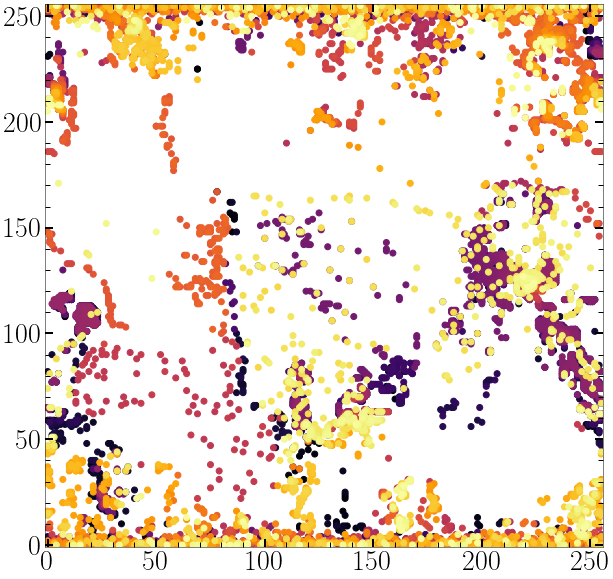

In [3]:
data = read_gz_with_pandas_nrows(f"{folderpath}/Avalanche_outputB.gz", cols = [2], nrows = nbpoints, read_last = True)

y, x = coorno(data, L1)
y = (L1-1) - y
x = np.reshape(x, (nbpoints))
y = np.reshape(y, (nbpoints))

print(x)
print(y)

fig, ax = plt.subplots(figsize = (10,10))
ax.set_xlim(-1, L1)
ax.set_ylim(-1, L2)
ax.tick_params(labelsize = 28,length = 8, width = 2)
ax.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

s = plt.scatter([], [])
all_x = []
all_y = []
all_colors = []

frames = 100
nbpoints_plot = nbpoints/frames

NCURVES = int(frames + 1)
cmap = plt.cm.get_cmap('inferno')
colors = itertools.cycle([cmap(i / NCURVES) for i in range(NCURVES)])

def epicenters(i):
    global x,y
    # Récupération des nouveaux points
    start_idx = int(nbpoints_plot * i)
    end_idx = int(nbpoints_plot * (i + 1))
    
    new_x = x[start_idx:end_idx]
    new_y = y[start_idx:end_idx]
    # Ajout des nouveaux points aux points précédents
    all_x.extend(new_x)
    all_y.extend(new_y)
    
    # Ajout de la nouvelle couleur pour chaque nouveau point
    new_color = [next(colors)] * len(new_x)
    all_colors.extend(new_color)
    
    # Mise à jour des offsets avec tous les points accumulés et leurs couleurs respectives
    s.set_offsets(np.column_stack([all_x, all_y]))
    s.set_facecolor(all_colors)
    
    if i == (frames - 1):
        x = np.zeros(0)
        y = np.zeros(0)
        return

# Création de l'animation
ani = animation.FuncAnimation(fig, epicenters, frames=frames, interval=200)

# Sauvegarde de l'animation sous forme de GIF
ani.save('epicenters.gif', writer='pillow')

The higher the dissipation the closer the epicenters will be in time and in space

# How do avalanches propagate?

In [4]:
def insys(x, y, L1, L2):
        if x == L1:
            x = 0
        elif x == -1:
            x = L1-1
            

        # if y == L2:
        #     y = 0
        # elif y == -1:
        #     y = L2 - 1
        return x, y

def neighbor(x, y, last_t, L1, L2):

    
    x_p, y_p = insys(x+1, y, L1, L2)
         
    if np.any(np.all(last_t == [x_p, y_p], axis = 1)):
        return True
    
    x_p, y_p = insys(x, y+1, L1, L2)
    if np.any(np.all(last_t == [x_p, y_p], axis = 1)):
        return True
    
    x_p, y_p = insys(x-1, y, L1, L2)
    if np.any(np.all(last_t == [x_p, y_p], axis = 1)):
        return True
    
    x_p, y_p = insys(x, y-1, L1, L2)
    if np.any(np.all(last_t == [x_p, y_p], axis = 1)):
        return True
    
    else:
        return False
    

In [5]:
folderpath ="/data1/DATA_Duplat/Brut/PDF/PD1n2"
file = f"{folderpath}/shape_outputB.txt"

L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]
data = []


with open(file) as f:
    
    for i, line in enumerate(f):
        col = line.strip().split(" ")
        
        col.reverse()
        col = np.array(col, dtype=int)
        y, x = coorno(col, L1)
        y = (L1-1) - y
        
        coo = np.column_stack((x, y))
        data.append(coo.tolist())
    


[(0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), 

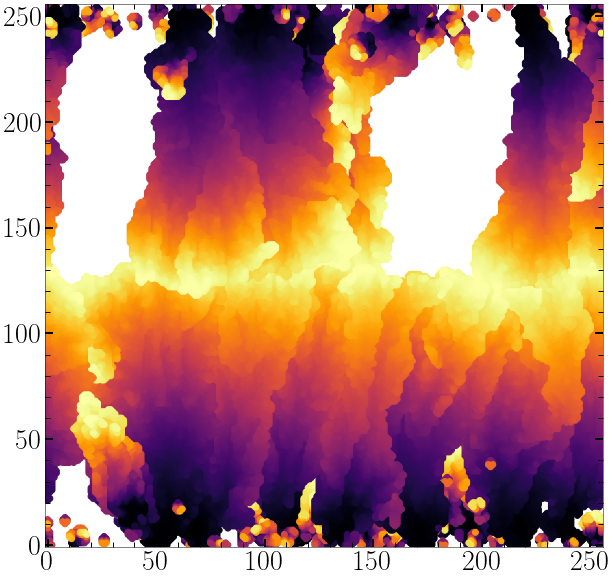

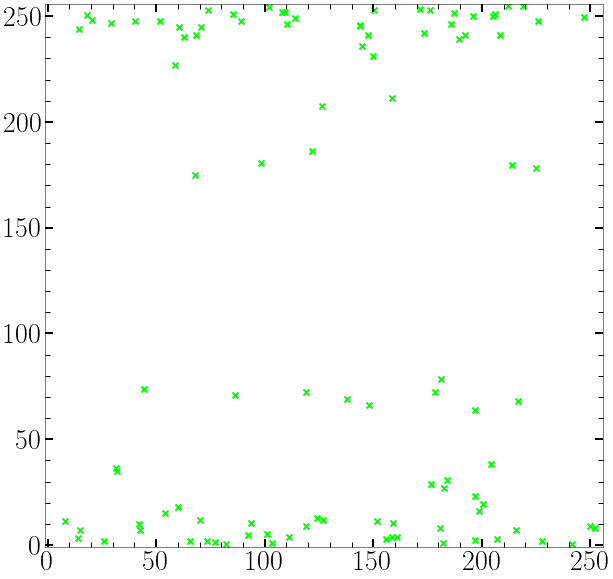

In [6]:
fig, ax = plt.subplots(figsize = (10,10))
ax.set_xlim(-1, L1)
ax.set_ylim(-1, L2)
ax.tick_params(labelsize = 28,length = 8, width = 2)
ax.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

s = plt.scatter([], [])
all_x = []
all_y = []
all_colors = []

frames = 100
def propagation(i):
    ava = data[i]
    x = [coo[0] for coo in ava]
    y = [coo[1] for coo in ava]

    epi = np.array([x[0], y[0]])
    last_t = np.array([epi])
    t = np.zeros((0, 2))

    tava = [[epi.tolist()]]
    for x_p, y_p in zip(x[1:], y[1:]):
        # print("t:", t)
        # print("lats_t: ", last_t)
        if neighbor(x_p, y_p, last_t, L1, L2):
            t = np.vstack((t, [x_p, y_p]))
        else:
            if len(t) > 0:
                tava.append(t.tolist())
                last_t = t
                t = np.array([[x_p, y_p]])
            if len(t) == 0:
                print(i)
                return

    tava.append(t.tolist())
    # print(tava)
    

    element_counts = [len(item) for item in tava]

    NCURVES = len(element_counts)
    cmap = plt.cm.get_cmap('inferno')
    colors = []

    for j, count in enumerate(element_counts):
        color = cmap(j / NCURVES)  
        colors.extend([color] * count)  
        
    # print(x)
    # print(y)
    # print(colors)
    # print(len(colors))
        
    
        
    all_x.extend(x)
    all_y.extend(y)
    all_colors.extend(colors)
    
    # print(all_colors)
    
    # print(all_x)
    # print(all_y)
    # print(all_colors)
    
    s.set_offsets(np.column_stack([all_x, all_y]))
    s.set_facecolor(all_colors)
    
    if i == (frames - 1):
        x.clear()
        y.clear()
        colors.clear()
        print(all_colors)
        return
    
    
ani = animation.FuncAnimation(fig, propagation, frames=frames, interval=200)

# Sauvegarde de l'animation sous forme de GIF
ani.save('propa.gif', writer='pillow')

#Center of masse

mass_center = np.zeros((len(data), 2))

for i in range(len(data)):
    ava = data[i]
    x = [coo[0] for coo in ava]
    y = [coo[1] for coo in ava]
    
    coo = np.column_stack((x, y))

    mass_center[i] = np.mean(coo, axis = 0)

plt.figure(figsize = (10,10))
plt.scatter(mass_center[:,0], mass_center[:,1], marker = 'x', color = 'lime', lw = 2)
plt.xlim(-1, L1)
plt.ylim(-1, L2)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()


## One avalanche

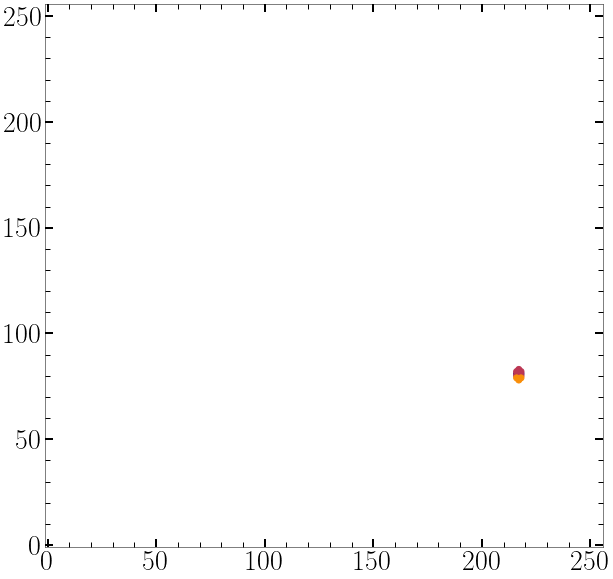

In [30]:
ava = data[90]

fig, ax = plt.subplots(figsize = (10,10))
ax.set_xlim(-1, L1)
ax.set_ylim(-1, L2)
ax.tick_params(labelsize = 28,length = 8, width = 2)
ax.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

s = plt.scatter([], [])
all_x = []
all_y = []
all_colors = []

x = [coo[0] for coo in ava]
y = [coo[1] for coo in ava]

coo = np.column_stack((x, y))

mass_center = np.mean(coo, axis = 0)

epi = np.array([x[0], y[0]])
last_t = np.array([epi])
t = np.zeros((0, 2))

tava = [[epi.tolist()]]
for x_p, y_p in zip(x[1:], y[1:]):
    if neighbor(x_p, y_p, last_t, L1, L2):
        t = np.vstack((t, [x_p, y_p]))
    else:
        if len(t) > 0:
            tava.append(t.tolist())
            last_t = t
            t = np.array([[x_p, y_p]])

tava.append(t.tolist())

# print(tava)
element_counts = [len(item) for item in tava]
idx = np.cumsum(element_counts)
idx = np.insert(idx, 0, 0)
idx[-1] = len(x)

NCURVES = len(element_counts)
cmap = plt.cm.get_cmap('inferno')
colors = []

for i, count in enumerate(element_counts):
    color = cmap(i / NCURVES)  
    colors.extend([color] * count)


# print(tava[-5:])
# print(element_counts)
# print(np.sum(element_counts))
# print(len(x))
# print(len(element_counts))
# print(len(idx))   
    
# frames = int(len(tava)/10)
frames = 20
step = math.floor(len(idx) / frames) if math.floor(len(idx) / frames) != 0 else 1

if step == 1: frames = len(idx) - 1
idx = idx[::step]

# print(idx)
# print(frames)
# print("x: ", x)
# print("y:", y)

def propagation_one(i):
    
    # print("i: ", i)
    # print(idx[i], idx[i+1])
    # print("x:", x)
    # print("y:", y)
    # print(x[idx[i]:0])
    if i == (frames - 1):
        all_x.extend(x[idx[i]:])
        all_y.extend(y[idx[i]:])
        all_colors.extend(colors[idx[i]:])
    else:
        all_x.extend(x[idx[i]:idx[i+1]])
        all_y.extend(y[idx[i]:idx[i+1]])
        all_colors.extend(colors[idx[i]:idx[i+1]])
    # print(all_x)

    # s.set_offsets(np.column_stack([all_x, all_y]))
    # s.set_facecolor(all_colors)
    
    # if idx[i+1] == len(x):
    #     print("test")
    #     return
    """ all_x.extend(x[:i+1])
    all_y.extend(y[:i+1])
    all_colors.extend(colors[:i+1]) """

    s.set_offsets(np.column_stack([all_x, all_y]))
    s.set_facecolor(all_colors)
    
    # print(all_x)
    # print(all_y)
    # print(all_colors)
    
    # print(len(all_x))
    # print(len(all_colors))
    
    if i == (frames - 1):
        x.clear()
        y.clear()
        colors.clear()
        return
        
    
    # Fin de l'animation après avoir montré tous les points
    # if i >= len(idx) - 2:
    #     plt.scatter(mass_center[0], mass_center[1], marker = 'x', color = 'lime', lw = 2)
    #     return
    

    
ani = animation.FuncAnimation(fig, propagation_one, frames=frames, interval=200, repeat=False)


# Sauvegarde de l'animation sous forme de GIF
ani.save('propa_one.gif', writer='pillow')
    
#[(0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.735683, 0.215906, 0.330245, 1.0), (0.735683, 0.215906, 0.330245, 1.0), (0.735683, 0.215906, 0.330245, 1.0), (0.735683, 0.215906, 0.330245, 1.0)]
#[(0.001462, 0.000466, 0.013866, 1.0), (0.001462, 0.000466, 0.013866, 1.0), (0.735683, 0.215906, 0.330245, 1.0), (0.735683, 0.215906, 0.330245, 1.0), (0.735683, 0.215906, 0.330245, 1.0), (0.735683, 0.215906, 0.330245, 1.0)]
